<a href="https://colab.research.google.com/github/Anggirahdillah/cats-dogs-image-classification-mobilenetv2/blob/main/classification_cats_and_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cats vs Dogs Image Classification using MobileNetV2**

This project implements binary image classification to distinguish between cats and dogs using MobileNetV2 and transfer learning.

### Objectives
- Perform image preprocessing for CNN-based classification.
- Apply data augmentation to the training dataset.
- Implement transfer learning using MobileNetV2 pretrained on ImageNet.
- Train and evaluate a binary image classification model.
- Analyze model performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
tf.keras.utils.set_random_seed(42)

## Dataset

The dataset consists of two classes:
- Cats
- Dogs

The data is divided into training, validation, and test sets.

In [2]:
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/klasifikasi cat and dog/dogs-vs-cats-classification.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

base_path = os.path.join(
    extract_path,
    "dogs-vs-cats-classification"
)

print("Dataset path:", base_path)

Mounted at /content/drive
Dataset path: /content/dataset/dogs-vs-cats-classification


In [3]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for root, _, files in os.walk(base_path):
    for filename in files:
        if filename.lower().endswith(image_extensions):
            path = os.path.join(root, filename)

            try:
                image = Image.open(path).convert("RGB")
                temp_path = path + ".tmp"

                if filename.lower().endswith((".jpg", ".jpeg")):
                    image.save(temp_path, format="JPEG", quality=95)
                elif filename.lower().endswith(".png"):
                    image.save(temp_path, format="PNG")
                elif filename.lower().endswith(".webp"):
                    image.save(temp_path, format="WEBP")
                else:
                    image.save(temp_path)

                os.replace(temp_path, path)

            except Exception:
                pass

print("Dataset preparation selesai.")

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dataset preparation selesai.


## Data Exploration

A sample image from each class is displayed to observe the dataset before preprocessing.

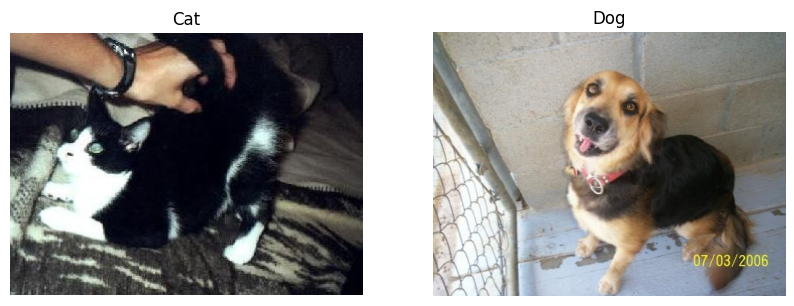

Original Cat Size: (350, 260)
Original Dog Size: (500, 375)


In [4]:
train_path = os.path.join(base_path, "train")
validation_path = os.path.join(base_path, "validation")
test_path = os.path.join(base_path, "test")

cat_path = os.path.join(train_path, "cats")
dog_path = os.path.join(train_path, "dogs")

cat_image = os.listdir(cat_path)[0]
dog_image = os.listdir(dog_path)[0]

cat = Image.open(os.path.join(cat_path, cat_image))
dog = Image.open(os.path.join(dog_path, dog_image))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cat)
plt.title("Cat")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dog)
plt.title("Dog")
plt.axis("off")

plt.show()

print("Original Cat Size:", cat.size)
print("Original Dog Size:", dog.size)

## Data Preprocessing

Images are resized to 224 × 224 pixels to match the input size required by MobileNetV2.

The dataset is loaded using TensorFlow's `image_dataset_from_directory`, which automatically assigns labels based on the class folder structure.

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_dataset.class_names)

Found 19943 files belonging to 2 classes.
Found 2492 files belonging to 2 classes.
Found 2495 files belonging to 2 classes.
Class names: ['cats', 'dogs']


## Data Augmentation

Random horizontal flipping is applied to the training images to improve the model's ability to generalize to variations in image orientation.

Data augmentation is applied only to the training dataset. Validation and test datasets are not randomly augmented.

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal")
])

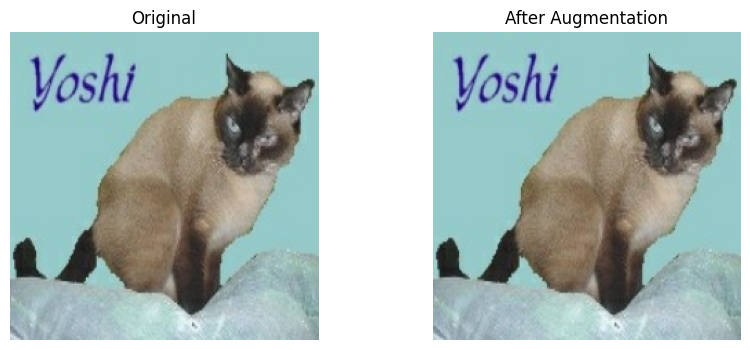

In [7]:
for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0].numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_images[0].numpy().astype("uint8"))
plt.title("After Augmentation")
plt.axis("off")

plt.show()

## 5. MobileNetV2 Transfer Learning

MobileNetV2 pretrained on ImageNet is used as the feature extraction backbone.

The pretrained layers are frozen, and a new classification layer is added for the binary cats vs dogs classification task.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## 6. MobileNetV2 Preprocessing

MobileNetV2 uses its own preprocessing function to scale input pixel values to the range expected by the pretrained model.

Training images are augmented before preprocessing, while validation and test images are only preprocessed.

In [9]:
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

train_mobilenet = train_dataset.map(
    lambda images, labels: (
        mobilenet_preprocess(data_augmentation(images)),
        labels
    )
)

validation_mobilenet = validation_dataset.map(
    lambda images, labels: (
        mobilenet_preprocess(images),
        labels
    )
)

test_mobilenet = test_dataset.map(
    lambda images, labels: (
        mobilenet_preprocess(images),
        labels
    )
)

## 7. Model Architecture

The model consists of:

1. MobileNetV2 as a pretrained feature extractor.
2. Global Average Pooling to reduce the spatial feature maps.
3. A single Dense layer with sigmoid activation for binary classification.

In [10]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

prediction_layer = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model(inputs, training=False)
x = global_average_layer(x)
outputs = prediction_layer(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 8. Model Training

The model is trained for 5 epochs using the Adam optimizer and binary cross-entropy loss.

The pretrained MobileNetV2 layers remain frozen during training.

In [12]:
history = model.fit(
    train_mobilenet,
    validation_data=validation_mobilenet,
    epochs=5
)

Epoch 1/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 113s 151ms/step - accuracy: 0.9724 - loss: 0.0771 - val_accuracy: 0.9900 - val_loss: 0.0339
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 67s 107ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9916 - val_loss: 0.0296
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 65s 103ms/step - accuracy: 0.9907 - loss: 0.0271 - val_accuracy: 0.9908 - val_loss: 0.0307
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.9917 - loss: 0.0240 - val_accuracy: 0.9912 - val_loss: 0.0287
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 69s 111ms/step - accuracy: 0.9922 - loss: 0.0220 - val_accuracy: 0.9924 - val_loss: 0.0288


## 9. Training Results

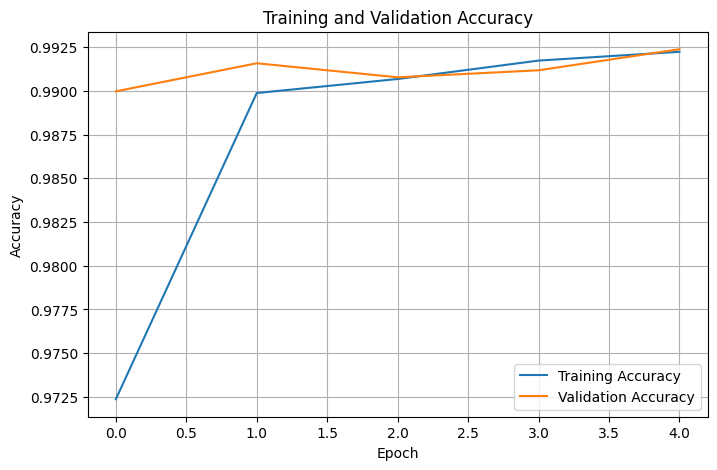

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

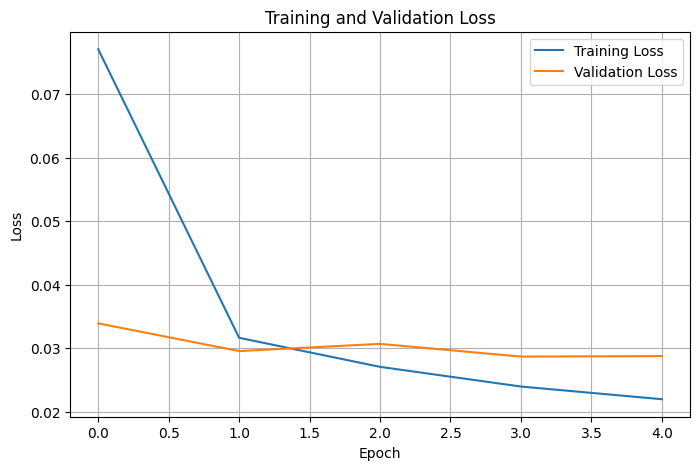

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

## 10. Model Evaluation

The trained model is evaluated on the test dataset, which was not used during model training.

In [15]:
test_loss, test_accuracy = model.evaluate(test_mobilenet)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

78/78 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.9876 - loss: 0.0328
Test Loss: 0.03280416131019592
Test Accuracy: 0.9875751733779907


## 11. Confusion Matrix

The confusion matrix is used to analyze correct and incorrect predictions for each class.

In [16]:
y_true = []
y_pred = []

for images, labels in test_mobilenet:
    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels.numpy())
    y_pred.extend(
        (predictions > 0.5).astype(int).flatten()
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [17]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1231   17]
 [  14 1233]]


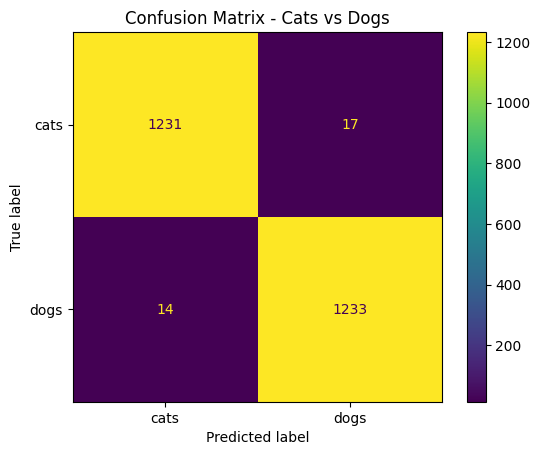

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.class_names
)

disp.plot()

plt.title("Confusion Matrix - Cats vs Dogs")
plt.show()

## 12. Classification Report

Precision, recall, and F1-score are used to provide a more detailed evaluation of the model's performance for each class.

In [19]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.class_names
    )
)

              precision    recall  f1-score   support

        cats       0.99      0.99      0.99      1248
        dogs       0.99      0.99      0.99      1247

    accuracy                           0.99      2495
   macro avg       0.99      0.99      0.99      2495
weighted avg       0.99      0.99      0.99      2495



## 13. Misclassified Images

The model incorrectly classified 26 out of 2,495 test images.

Examples of misclassified images are displayed below to analyze cases where the model's prediction differs from the actual label.

In [20]:
wrong_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Number of misclassified images:",
    len(wrong_indices)
)

Number of misclassified images: 31


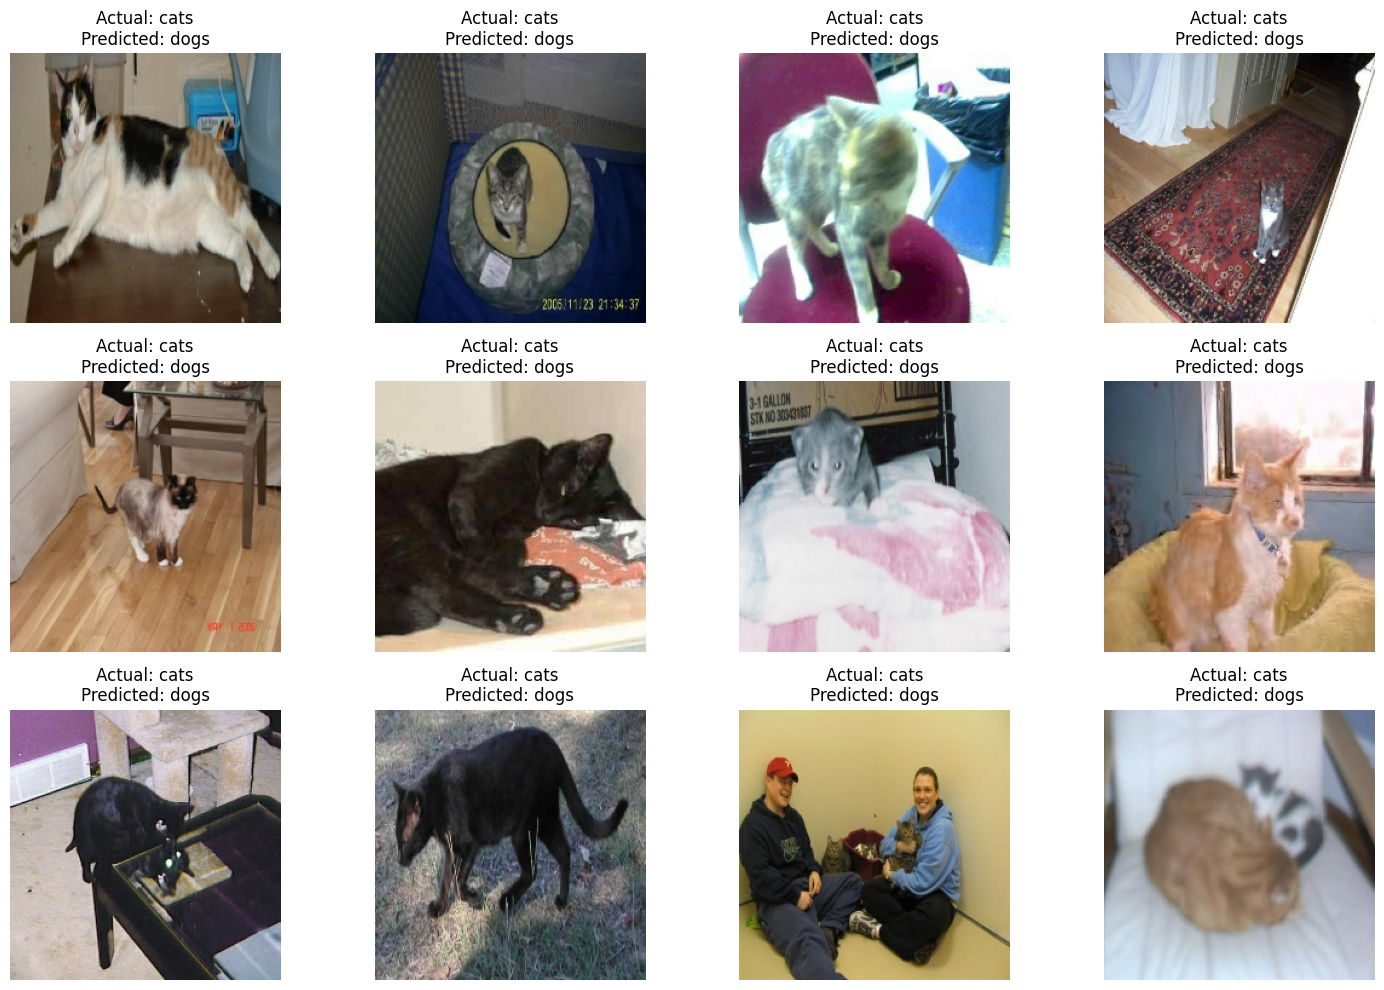

In [21]:
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(wrong_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(
        test_images[idx].astype("uint8")
    )

    actual = train_dataset.class_names[
        test_labels[idx]
    ]

    predicted = train_dataset.class_names[
        y_pred[idx]
    ]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Conclusion

The MobileNetV2 transfer learning model achieved a test accuracy of 98.96% on the Cats vs Dogs classification task.

The confusion matrix shows that most images were correctly classified, with 26 misclassified images out of 2,495 test images.

The classification report also shows balanced performance between the cats and dogs classes, with an F1-score of 0.99 for both classes.

Overall, the experiment demonstrates that MobileNetV2 with transfer learning can achieve high performance for binary image classification.

## Project Summary

| Component | Configuration |
|---|---|
| Task | Binary Image Classification |
| Classes | Cats, Dogs |
| Model | MobileNetV2 |
| Pretrained Weights | ImageNet |
| Input Size | 224 × 224 × 3 |
| Batch Size | 32 |
| Epochs | 5 |
| Optimizer | Adam |
| Loss Function | Binary Crossentropy |
| Test Accuracy | 98.76% |
| Test Loss | 0.0328 |
| Misclassified Images | 31 / 2,495 |